# IRTモデルの仮定

標準的なIRTモデルの仮定

1. **一次元性** ：能力は1次元で表せる
2. **局所独立性** ：$\theta$で条件づけた下での項目間の独立性。尤度関数の構築のために仮定。


### 一次元性

2PLMのように1次元の能力パラメータ$\theta$をもつモデルは、能力が1次元で表せることを仮定している。  
データがこのモデルに合っているかどうかを確かめる必要がある

:::{note}

1次元ではなく$D$次元のスコアを推定する多次元IRTモデルの場合はこの仮定は置かない。  
しかしモデルが次元数について仮定するのは同じ。

:::

#### 検証方法

スクリープロットを描き、第1主成分が突出して高ければ一次元性を満たすと判断する。厳密な判断基準はない。

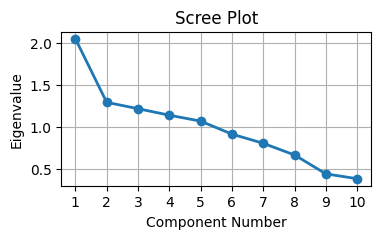

In [35]:
# ------------------------------
# サンプルデータの生成
# ------------------------------
import numpy as np
import pandas as pd

np.random.seed(42)

n_persons = 100
n_items = 10

# 能力θと項目困難度bを設定
theta = np.random.normal(0, 1, n_persons)
b = np.random.normal(0, 0.2, n_items)
a = np.random.normal(0, 0.1, n_items)

# 2PLMで応答を生成
prob = 1 / (1 + np.exp(- a * (theta[:, None] - b)))
responses = np.random.binomial(1, prob)

df = pd.DataFrame(responses, columns=[f"item_{i+1}" for i in range(n_items)])
# print(df.head())

# ------------------------------
# スクリープロット
# ------------------------------
import numpy as np
from ordinalcorr import hetcor

cor_matrix = hetcor(df)
eigenvalues, _ = np.linalg.eig(cor_matrix)
eigenvalues = np.sort(eigenvalues)[::-1]

import matplotlib.pyplot as plt
plt.figure(figsize=(4, 2))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.title("Scree Plot")
plt.xlabel("Component Number")
plt.ylabel("Eigenvalue")
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True)
plt.show()

### 局所独立性（local independence）

**局所独立性（local independence）** の定義は「能力$\theta$の値を固定したもとで、各項目の反応$u_j$は独立」というもの。

局所独立性が仮定される理由は2つある

1. $\theta$が反応傾向の変動要因だから
2. 尤度関数が作りやすいから

#### 1. $\theta$が反応傾向の変動要因だから

IRTモデルでは、各項目への反応傾向（正答率）$u_{j}$が変化する要因は$\theta$であると仮定して項目反応曲線をモデリングしている。

$\theta$が各項目の反応$u_j$に影響しているため、$\theta$が反応同士$u_j, u_l$の疑似相関$corr(u_j, u_l)$を起こす第3の変数（交絡因子）になっている状態。しかし$\theta$の値を固定する（統制する）と、この疑似相関は消えるはず。

もし$\theta$以外に$u_j$に影響を与える共通の要因（$\theta$以外の交絡因子）があるなら、局所独立性が満たされない。ということ。

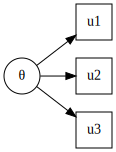

In [7]:
import graphviz

graphviz.Source("""
digraph g {
    graph [rankdir = LR];
    node [shape = square];
    u1
    u2
    u3
    node [shape = circle];
    theta [label="θ"]

    theta -> {u1, u2, u3}
    {rank = same; u1, u2, u3}
}
""")

#### 2. 尤度関数が作りやすいから

尤度関数（≒反応パターンの同時分布）を各項目の積

$$
\begin{aligned}
L(\mathbf{T}, \boldsymbol{\theta} \mid \mathbf{U})
&=\prod_{i=1}^I \prod_{j=1}^J P_j(\theta_i \mid \mathbf{T})^{u_{i j}} \cdot \{ 1 - P_j(\theta_i \mid \mathbf{T}) \} ^{1-u_{i j}}
\end{aligned}
$$

とするために、$\theta$で条件づけた下での項目間の独立性を仮定している。
（なお$\mathbf{T}$は項目パラメータ、$u_{i j}$は二値の反応、$\mathbf{U}$は反応パターン行列、$P_j(\theta_i \mid \mathbf{T})$はICC）


局所独立性の正確な検証は難しいが、$Q_3$統計量が参考によく用いられる。

:::{admonition} $Q_3$統計量

$Q_3$統計量は任意の項目のペア$j$と$j^\prime$の間の局所独立性の指標として次のように定義される。

$$
Q_{3, j j^{\prime}} := r(e_j, e_{j^{\prime}})
$$

ここで：

- $r(\cdot, \cdot)$：相関係数
- $e_{ij} := u_{ij} - \hat{P}_j(\hat{\theta}_i)$ ：推定値によるICC$\hat{P}_j(\hat{\theta}_i)$と実測値$u_{ij}$の残差得点

:::

$Q_3$統計量は

- $\theta$によって項目間の相関関係が十分に説明されているとすれば、その影響を除去した残差得点同士の相関は0に近くなるはず
- $\theta$以外に項目間に相関をもたらす要因がある場合は$\theta$の影響を除いてもなお相関が残る

という考え方をとっている。

目安としては、「$Q_3 > 0.20$の項目ペアは局所独立性の侵害を疑う必要がある」とされるが0.20も絶対の閾値ではない。

### 局所依存性があるとどうなるのか？

局所依存性を考慮した場合に比べて項目母数の推定誤差が増加（[登藤直弥. 2012. 項目反応間の局所依存性が項目母数の推定に与える影響](https://www.jstage.jst.go.jp/article/pacjpa/76/0/76_1EVA19/_article/-char/ja/)）
